<a href="https://colab.research.google.com/github/PawaniMekhala/AI-Driven-Student-Dropout-Prediction/blob/main/03_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/student-dropout-prediction"

# Load train data
X_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_train.csv")
y_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_train.csv")

# Load test data
X_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_test.csv")
y_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_test.csv")

# Flatten target arrays
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# Quick sanity check
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


Mounted at /content/drive
(3539, 226) (3539,)
(885, 226) (885,)


In [ ]:
# Train Logistic Regression model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with class weights
log_reg = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [ ]:
# Logistic Regression Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_lr = log_reg.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88       601
           1       0.73      0.80      0.77       284

    accuracy                           0.84       885
   macro avg       0.82      0.83      0.82       885
weighted avg       0.85      0.84      0.84       885



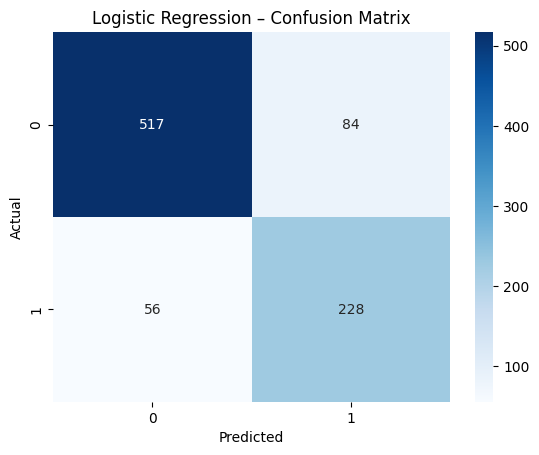

In [ ]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression – Confusion Matrix")
plt.show()

In [ ]:
tn, fp, fn, tp = cm_lr.ravel()

print(f"""
Confusion Matrix:
-----------------
            Predicted
            0     1
Actual 0   {tn}    {fp}
Actual 1   {fn}    {tp}
""")


Confusion Matrix:
-----------------
            Predicted
            0     1
Actual 0   517    84
Actual 1   56    228



Logistic Regression ROC-AUC: 0.8967390030700008


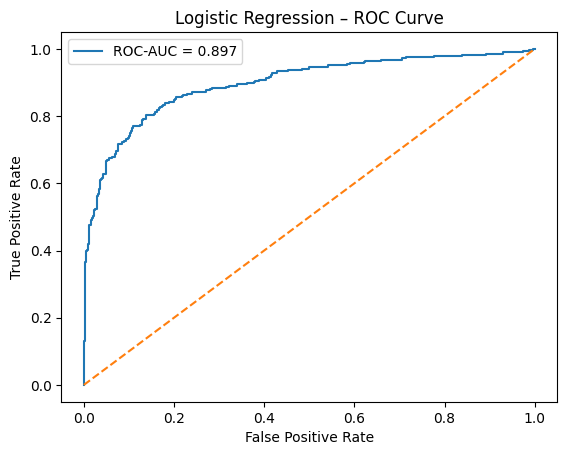

In [ ]:
# add new need to add for doc
from sklearn.metrics import roc_auc_score, roc_curve

# Predicted probabilities
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob_lr)
print("Logistic Regression ROC-AUC:", roc_auc)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression – ROC Curve")
plt.legend()
plt.show()


In [ ]:
# Save Logistic Regression results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr)],
    "Precision": [precision_score(y_test, y_pred_lr)],
    "Recall": [recall_score(y_test, y_pred_lr)],
    "F1-score": [f1_score(y_test, y_pred_lr)]
})

lr_results.to_csv(
    f"{PROJECT_ROOT}/results/metrics/logistic_regression_results.csv",
    index=False
)

lr_results


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.841808,0.730769,0.802817,0.765101


In [ ]:
# Train a Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,        # prevents overfitting
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [ ]:
# Decision Tree Evaluation
# Predict on test data
y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       601
           1       0.70      0.81      0.75       284

    accuracy                           0.83       885
   macro avg       0.80      0.82      0.81       885
weighted avg       0.84      0.83      0.83       885



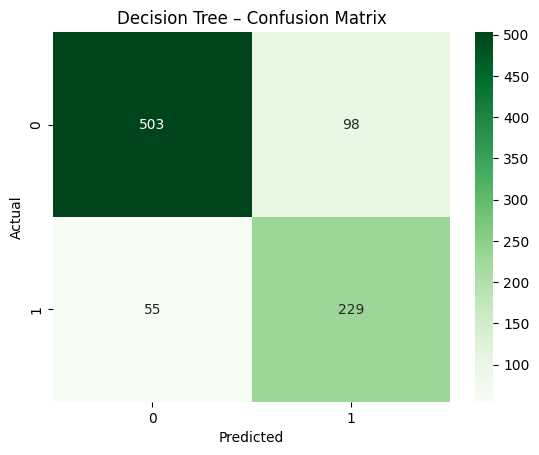

In [ ]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree – Confusion Matrix")
plt.show()

In [ ]:
tn, fp, fn, tp = cm_dt.ravel()

print(f"""
Decision Tree Confusion Matrix:
------------------------------
            Predicted
            0     1
Actual 0   {tn}    {fp}
Actual 1   {fn}    {tp}
""")


Decision Tree Confusion Matrix:
------------------------------
            Predicted
            0     1
Actual 0   503    98
Actual 1   55    229



In [ ]:
dt_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [accuracy_score(y_test, y_pred_dt)],
    "Precision": [precision_score(y_test, y_pred_dt)],
    "Recall": [recall_score(y_test, y_pred_dt)],
    "F1-score": [f1_score(y_test, y_pred_dt)]
})

dt_results.to_csv(
    f"{PROJECT_ROOT}/results/metrics/decision_tree_results.csv",
    index=False
)

dt_results


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.827119,0.700306,0.806338,0.749591


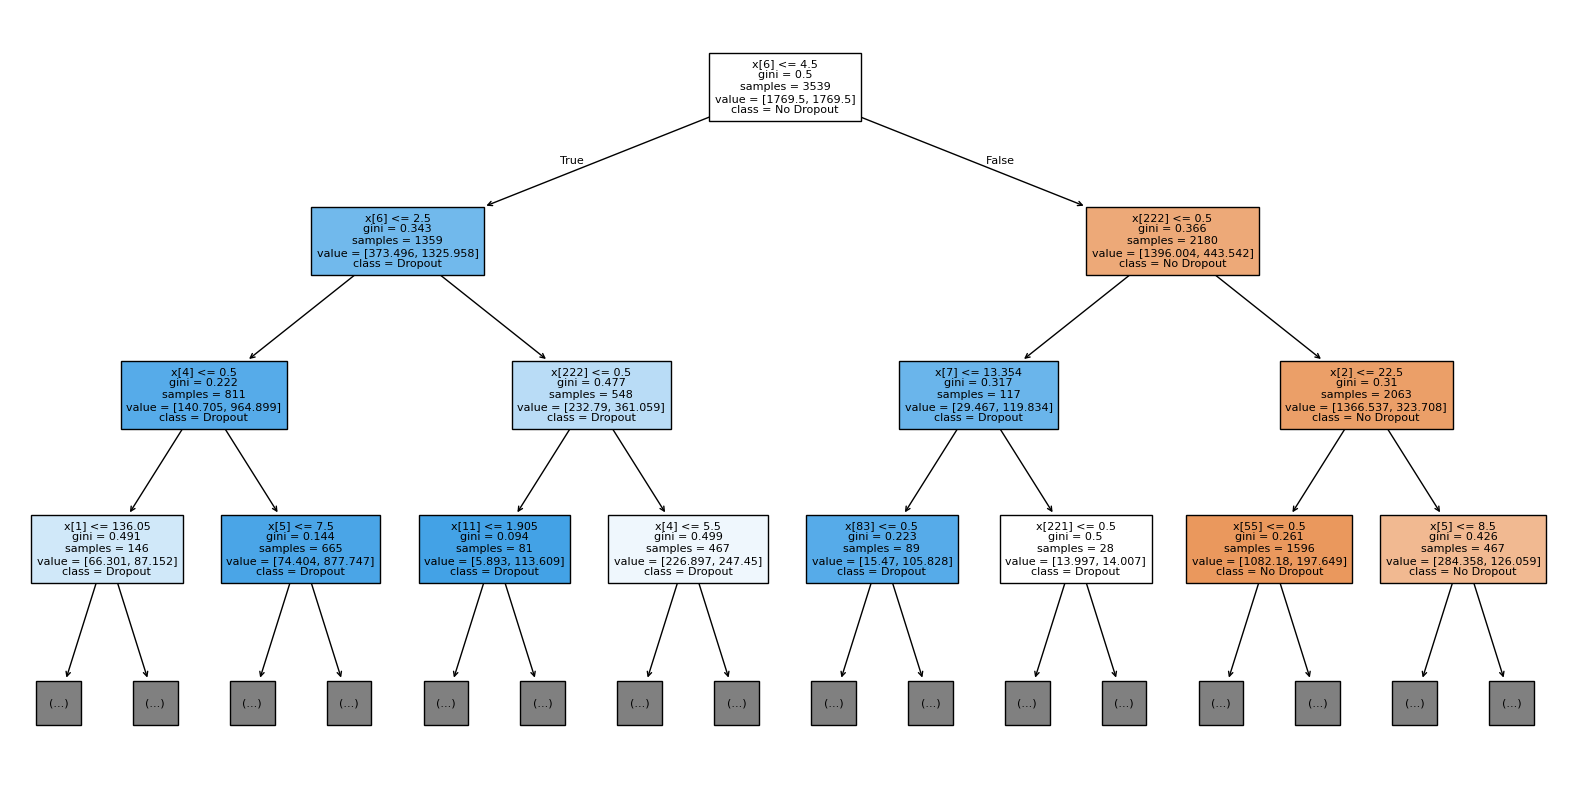

In [ ]:
# Visualize Decision Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt,
    class_names=["No Dropout", "Dropout"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.show()
